# Projet 02 - Machine Learning : Qui gagnera la Coupe du Monde 2026 ?

*Temps estimé : 60 - 90 minutes*

Bienvenue dans le deuxième projet du cahier de vacances Machine Learnia !

<div align="center">
<img src="./image.png" alt="ouvrir dans VSCode pour voir l'image" width="800"/>
</div>

Ton avion s'est posé à Athènes, la valise est à l'hôtel, et te voilà attablé dans une petite taverne du quartier de Plaka. Avec tes amis, vous regardez la coupe du monde de Football 2026... Et les pronostics commencent sur le vainceur final !

Thomas jure que la France est la meilleure. Yannis mise sur l'Argentine. Chacun a son avis, son intuition, son équipe de coeur. Toi, tu souris : tu as quelque chose que personne d'autre n'a autour de la table. Des données. __Trente ans de résultats de matchs internationaux__, et de quoi entraîner une machine à faire des pronostics.

Le but de ce TP est de te glisser dans la peau d'un data scientist qui prend le pari fou de la taverne :

**Prédire le gagnant de la prochaine coupe du monde de football avec l'IA**


À la fin du projet, tu auras construit un modèle de Machine Learning capable de prédire le vainqueur d'un match de football, et tu pourras meme l'utiliser pour simuler tout un tableau, comme pour la prochaine édition de la coupe du monde qui aura lieu en 2030, des seizièmes de finale jusqu'à la finale. Pas besoin d'être un expert : on part de zéro, chaque étape est expliquée, et chaque exercice vérifie tout seul que ta réponse est la bonne.

### L'outil du jour : le Machine Learning

Rappelons-nous de ce qu'est le Machine Learning. L'idée tient en une phrase : au lieu d'écrire nous-mêmes les règles ("une équipe qui marque beaucoup gagne souvent"), on montre à un programme des milliers d'exemples du passé, et c'est lui qui découvre les règles tout seul. C'est exactement comme ça que fonctionnent les recommandations de Netflix, les filtres anti-spam ou les prévisions météo : des exemples, un algorithme qui apprend, des prédictions.

Pour ça, on utilisera `scikit-learn`, LA librairie de référence du Machine Learning en Python. Elle est utilisée partout, de la startup au laboratoire de recherche, et sa grande force est de rendre les choses simples : quelques lignes suffisent pour entraîner un modèle.

Au programme : explorer les données avec des graphiques, les préparer pour l'apprentissage, entraîner un modèle de prédiction, puis l'utiliser pour prédire le vainqueur de la coupe du monde !

En bonus, on pourra  simuler la Coupe du Monde 2030 match après match.

# Avant tout : Import de nos librairies

Si tu as fait le premier projet, ton environnement Python (le dossier `.venv` créé avec `uv`) est déjà en place, avec `pandas` et `ipykernel` dedans. Sinon, retourne voir le tutoriel du README du repo, il explique tout depuis le début.

Pour ce projet, on ajoute trois librairies :

- `pandas` : notre couteau suisse pour manipuler les données en tableaux (les DataFrames). Déjà installée au projet 1.
- `matplotlib` : la librairie de référence pour tracer des graphiques. On s'en servira beaucoup, un bon graphique vaut mille tableaux. Déjà installée au projet 1.
- `scikit-learn` : la librairie de Machine Learning dont on vient de parler. C'est elle qui fournit le modèle qu'on va entraîner.

Pour les ajouter à l'environnement, ouvre un terminal à la racine du projet et tape :

```shell
uv add scikit-learn
```

### Cette fois-ci, j'ai ajouté un fichier `utils.py`

Nouveauté de ce projet : à côté du notebook, tu trouveras un fichier `utils.py`. Je l'ai rajouter pour "cacher" certaines fonctions "de plomberie" du projet, afin de ne pas surcharger ce notebook. Je vous encourage à le consulter pour voir ce qu'il s'y trouve (charger le fichier de données, calculer des statistiques d'historique, afficher joliment les résultats du tournoi).

C'est une pratique très courante en data science : on garde le notebook pour le raisonnement, et on range le code technique dans des fichiers Python à part. Le notebook reste lisible, et les fonctions sont réutilisables. Les noms des fonctions sont explicites, et si tu es curieux, ouvre le fichier pour voir comment elles marchent !

Sélectionne le kernel de ton environnement (`Select Kernel` en haut à droite, choisis celui qui mentionne `.venv`), et lançons nos imports :

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from utils import (
    ROUND_NAMES,
    add_recent_form,
    get_current_form,
    load_results,
    print_champion,
    print_round,
    team_label,
)

# Partie 1 - Les données : 30 ans de football international

Pour prédire l'avenir, il faut d'abord connaître le passé. Bonne nouvelle : des passionnés maintiennent un jeu de données librement réutilisable (licence CC0, domaine public) qui recense TOUS les matchs internationaux de football depuis 1872. Plus de 49 000 matchs : Coupes du Monde, championnats continentaux, qualifications, matchs amicaux...

Les données d'origine sont disponibles ici https://github.com/martj42/international_results

Mais inutile de les télécharger toi-meme, car je les ai directement placé pour toi dans le dossier data de ton dépot. Regarde, en principe tu dois avoir cette structure :

```txt
Projet_02/
├── data/
│   └── results.csv
├── projet_02.ipynb
└── utils.py
```

### Analyse du Dataset

Quand on ouvre le fichier, on observe que Chaque ligne du fichier correspond à un match, avec les colonnes suivantes :

| Colonne | Description |
|---|---|
| `date` | la date du match |
| `home_team` | l'équipe qui reçoit |
| `away_team` | l'équipe qui se déplace |
| `home_score` | buts de l'équipe à domicile |
| `away_score` | buts de l'équipe à l'extérieur |
| `tournament` | le type de compétition (Coupe du Monde, amical...) |
| `city`, `country` | où le match a été joué |
| `neutral` | `True` si le match s'est joué sur terrain neutre |

La cellule ci-dessous charge le fichier avec la fonction `load_results` de `utils.py` (elle ajoute aussi une colonne `year` bien pratique). Si le fichier n'est pas au bon endroit, elle te le dira gentiment.

In [4]:
df = load_results("data/results.csv")

print(f"{len(df)} matchs chargés, de {df['year'].min()} à {df['year'].max()}")
display(df.head())

assert len(df) > 45000, "Le fichier semble incomplet, retélécharge-le depuis GitHub"
assert list(df.columns[:6]) == ['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament'], \
    "Les colonnes ne correspondent pas, vérifie que tu as bien téléchargé results.csv"
print("Données chargées, on peut y aller !")

49505 matchs chargés, de 1872 à 2026


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,year
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False,1872
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False,1873
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False,1874
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False,1875
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False,1876


Données chargées, on peut y aller !


### Ton premier exercice : Filtrer le Dataset pour se limiter à l'ère moderne

Comme on peut le constater dans le tableau ci-dessus, nos données démarrent en 1872...

Disons le... le football de 1872 n'a plus grand-chose à voir avec celui d'aujourd'hui (matchs en pantalon de flanelle, 20 passes par match). Pour que notre modèle apprenne des choses encore valables en 2026-2030, on va se limiter à l'ère moderne : les matchs joués entre le 1er janvier 1994 et le 30 juin 2026.

Pourquoi une borne de fin ? Le dataset est mis à jour en permanence. En la figeant au 30 juin 2026, on travaille tous sur les mêmes matchs, peu importe le jour où tu as téléchargé le fichier.

À toi de jouer : filtre le DataFrame `df` pour ne garder que les matchs entre ces deux dates (incluses).

> Indice : en pandas, on filtre avec `df[condition]`, et on combine deux conditions avec `&` en mettant chacune entre parenthèses : `df[(condition_1) & (condition_2)]`. La colonne `date` se compare directement à un texte comme `"1994-01-01"`.

> Ressource Gratuite : Si tu as besoin de découvrir ou redécouvrir `Pandas`, j'ai réaliser cette formation gratuite il y a quelques années :   https://www.youtube.com/watch?v=zZkNOdBWgFQ&list=PLO_fdPEVlfKqMDNmCFzQISI2H_nJcEDJq&index=17

In [5]:
### START CODE HERE ###
df = df[
    (df["date"] >= "1994-01-01") &
    (df["date"] <= "2026-06-30")
]
### END CODE HERE ###

print(f"{len(df)} matchs conservés, de {df['year'].min()} à {df['year'].max()}")

assert df["year"].min() == 1994, f"Le premier match doit dater de 1994, pas de {df['year'].min()}"
assert str(df["date"].max()) <= "2026-06-30 00:00:00", "Il reste des matchs après le 30 juin 2026"
assert 28000 < len(df) < 32000, f"Tu devrais avoir environ 30 000 matchs, tu en as {len(df)}"
print("Exercice validé !")

29981 matchs conservés, de 1994 à 2026
Exercice validé !


### Débat #1 : l'avantage du terrain, mythe ou réalité ?

Premier débat à trancher dans la taverne : Yannis affirme que jouer à domicile, "c'est déjà un but d'avance". A-t-il raison ? Les données vont nous le dire.

Commençons par ajouter une colonne `outcome` qui résume le résultat de chaque match : victoire à domicile, match nul, ou victoire à l'extérieur. On te la donne, exécute simplement la cellule :

In [6]:
df = df.copy()
df["outcome"] = "draw"
df.loc[df["home_score"] > df["away_score"], "outcome"] = "home_win"
df.loc[df["home_score"] < df["away_score"], "outcome"] = "away_win"

display(df["outcome"].value_counts())

outcome
home_win    14545
away_win     8445
draw         6991
Name: count, dtype: int64

Maintenant, à toi : pour mesurer l'avantage du terrain, il faut écarter les matchs sur terrain neutre (personne n'y est "à domicile"), puis calculer la **proportion** de chaque résultat.

> Indice : `df[df["neutral"] == False]` garde les matchs avec un vrai terrain à domicile, et `.value_counts(normalize=True)` sur la colonne `outcome` donne les proportions plutôt que les comptes.

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,year,outcome
19503,1994-01-02,Barbados,Grenada,0.0,0.0,Friendly,Bridgetown,Barbados,False,1994,draw
19504,1994-01-02,Ghana,Egypt,2.0,1.0,Friendly,Accra,Ghana,False,1994,home_win
19505,1994-01-05,Mali,Burkina Faso,1.0,1.0,Friendly,Bamako,Mali,False,1994,draw
19506,1994-01-09,Mauritania,Mali,1.0,3.0,Friendly,Nouakchott,Mauritania,False,1994,away_win
19507,1994-01-11,Thailand,Nigeria,1.0,1.0,Friendly,Bangkok,Thailand,False,1994,draw


outcome
home_win    0.509069
away_win    0.258544
draw        0.232387
Name: proportion, dtype: float64

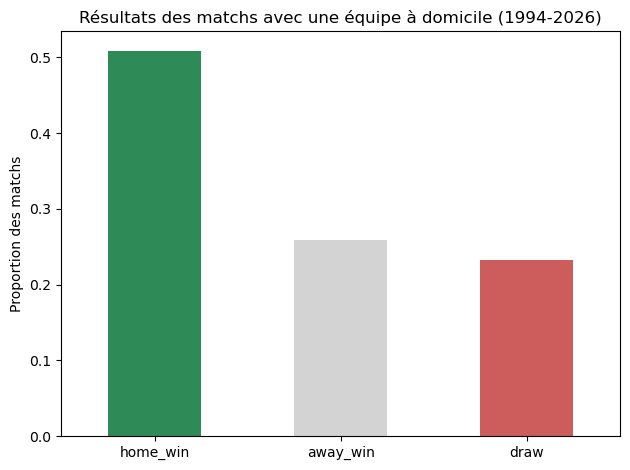

Exercice validé ! Yannis n'a pas tort : à domicile, on gagne 1 match sur 2.


In [9]:
### START CODE HERE ###
df_home = df[df["neutral"] == False]    
display(df_home.head())
home_advantage = df_home["outcome"].value_counts(normalize=True)
### END CODE HERE ###

display(home_advantage)

home_advantage.plot(kind="bar", color=["seagreen", "lightgray", "indianred"])
plt.title("Résultats des matchs avec une équipe à domicile (1994-2026)")
plt.ylabel("Proportion des matchs")
plt.xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

assert abs(home_advantage.sum() - 1.0) < 0.01, "Les proportions doivent sommer à 1, utilise normalize=True"
assert home_advantage["home_win"] > home_advantage["away_win"], "Étrange, vérifie ton filtre sur neutral"
assert 0.45 < home_advantage["home_win"] < 0.55, f"La proportion de victoires à domicile devrait avoisiner 0.50"
print("Exercice validé ! Yannis n'a pas tort : à domicile, on gagne 1 match sur 2.")

### Débat #2 : quels sont les cadors de l'ère moderne ?

Deuxième débat : quelles équipes gagnent le plus depuis 1994 ? Thomas affirme que de le Brésil est toujours dans le top 3. Vérifions en comptant le nombre total de victoires de chaque équipe.

Petite subtilité : une équipe peut gagner à domicile (elle apparaît dans `home_team` quand `outcome` vaut `"home_win"`) ou à l'extérieur (dans `away_team` quand `outcome` vaut `"away_win"`). Il faut compter les deux, puis les additionner.

> Indice : `.value_counts()` compte les apparitions, et `serie_1.add(serie_2, fill_value=0)` additionne deux comptages en gérant les équipes absentes d'un des deux. Termine avec `.sort_values(ascending=False).head(10)`.

Brazil           317.0
Mexico           310.0
Spain            274.0
United States    273.0
Japan            266.0
France           264.0
Germany          264.0
Saudi Arabia     260.0
Argentina        258.0
Iran             248.0
Name: wins, dtype: float64

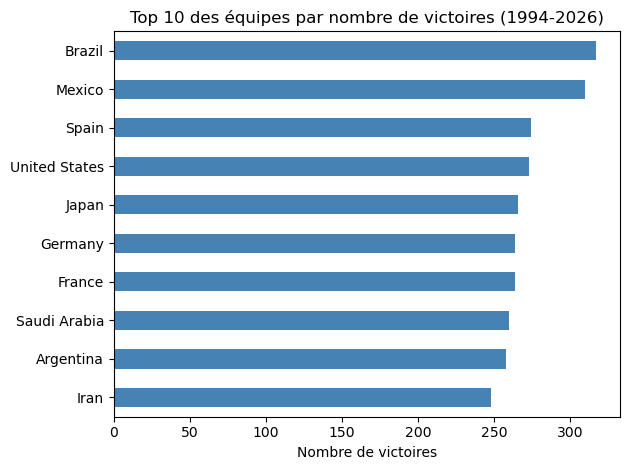

Exercice validé !


In [10]:
### START CODE HERE ###
home_wins = df[df["outcome"] == "home_win"]["home_team"].value_counts()
away_wins = df[df["outcome"] == "away_win"]["away_team"].value_counts()

top_10_teams = (
    home_wins
    .add(away_wins, fill_value=0)
    .sort_values(ascending=False)
    .head(10)
)

top_10_teams = top_10_teams.rename("wins")
### END CODE HERE ###

display(top_10_teams)

top_10_teams.sort_values().plot(kind="barh", color="steelblue")
plt.title("Top 10 des équipes par nombre de victoires (1994-2026)")
plt.xlabel("Nombre de victoires")
plt.tight_layout()
plt.show()

assert len(top_10_teams) == 10, f"Il faut exactement 10 équipes, tu en as {len(top_10_teams)}"
assert "Brazil" in top_10_teams.index, "Le Brésil devrait être dans le top 10, vérifie tes comptages"
assert top_10_teams.is_monotonic_decreasing, "Trie du plus grand au plus petit nombre de victoires"
print("Exercice validé !")

### Débat #3 : le foot moderne est-il plus offensif ?

Dernier débat avant de passer aux choses sérieuses : le patron de la taverne soupire que "le foot d'avant, c'était plus de buts". Voyons l'évolution du nombre moyen de buts par match, année par année.

> Indice : crée d'abord une colonne `total_goals` (somme des buts des deux équipes), puis utilise `df.groupby("year")["total_goals"].mean()` pour obtenir la moyenne par année.

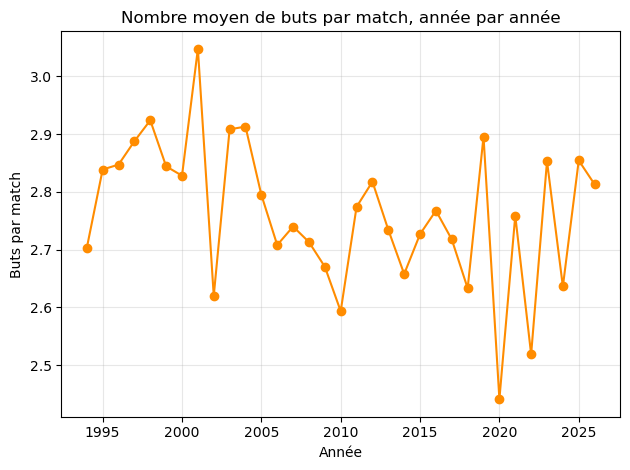

Exercice validé ! Autour de 2.7 buts par match, plutôt stable : le patron exagère.


In [11]:
### START CODE HERE ###
# Nombre total de buts par match
df["total_goals"] = df["home_score"] + df["away_score"]

# Moyenne de buts par année
goals_per_year = df.groupby("year")["total_goals"].mean()

goals_per_year
### END CODE HERE ###

goals_per_year.plot(kind="line", marker="o", color="darkorange")
plt.title("Nombre moyen de buts par match, année par année")
plt.ylabel("Buts par match")
plt.xlabel("Année")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

assert len(goals_per_year) > 30, "Il devrait y avoir une valeur par année depuis 1994"
assert goals_per_year.between(2, 4).all(), "Les moyennes devraient toutes être entre 2 et 4 buts par match"
print("Exercice validé ! Autour de 2.7 buts par match, plutôt stable : le patron exagère.")

# Partie 2 - Préparer les données pour le Machine Learning

L'échauffement est terminé, on connaît nos données. Place à la préparation, l'étape la moins glamour mais la plus importante de tout projet de Machine Learning (les data scientists y passent souvent plus de temps qu'à modéliser !).

Le principe : un modèle de Machine Learning n'apprend que sur des **nombres**. Il faut donc transformer chaque match en une liste de nombres qui le décrivent (on appelle ça les **features**, les caractéristiques d'entrée) et un résultat à prédire (la **target**, la cible). Notre plan :

- pour chaque match, décrire la **forme récente** des deux équipes au moment du match (features)
- indiquer au modèle qui a gagné (target)

Le modèle apprendra alors le lien entre "état de forme des deux équipes" et "résultat du match". Et le jour où on lui présentera France - Brésil version 2030, il saura se prononcer.

### Étape 1 : la forme récente des équipes

Comment décrire la force d'une équipe à un instant donné ? Une idée simple et efficace : regarder ses 10 derniers matchs. Une équipe qui a pris beaucoup de points et marqué beaucoup de buts récemment est en forme, c'est cette forme qu'on donne à manger au modèle.

Le calcul (parcourir les matchs dans l'ordre et maintenir l'historique de chaque équipe) est un peu technique et c'est pourquoi je l'ai directement fait pour vous dans le fichier `utils.py` (allez le voir) ! La fonction `add_recent_form` ajoute 6 colonnes à notre DataFrame, calculées pour chaque match **avec les informations disponibles avant le coup d'envoi** (très important : le modèle ne doit jamais tricher en regardant le futur) :

- `home_avg_points`, `home_avg_goals_scored`, `home_avg_goals_conceded` : points moyens (victoire = 3, nul = 1, défaite = 0), buts marqués et encaissés en moyenne par l'équipe à domicile sur ses 10 derniers matchs
- les 3 mêmes colonnes en `away_` pour l'équipe à l'extérieur

Les premiers matchs de chaque équipe n'ont pas assez d'historique : ils reçoivent des valeurs manquantes (NaN) et on les écarte. Exécute la cellule :

In [12]:
df = add_recent_form(df, window=10, min_matches=5)
df = df.dropna(subset=["home_avg_points", "away_avg_points"]).reset_index(drop=True)

print(f"{len(df)} matchs avec la forme récente des deux équipes")
display(df[["date", "home_team", "away_team", "home_avg_points", "away_avg_points"]].tail())

assert "home_avg_points" in df.columns, "La colonne home_avg_points est absente, relance la cellule"
assert df["home_avg_points"].between(0, 3).all(), "Des points moyens hors de l'intervalle [0, 3] ?!"
print("Forme récente calculée !")

28827 matchs avec la forme récente des deux équipes


,date,home_team,away_team,home_avg_points,away_avg_points
28822,2026-06-29,Brazil,Japan,2.0,2.4
28823,2026-06-29,Germany,Paraguay,2.7,1.4
28824,2026-06-30,Mexico,Ecuador,2.6,1.7
28825,2026-06-30,France,Sweden,2.5,1.2
28826,2026-06-30,Ivory Coast,Norway,2.2,1.8


Forme récente calculée !


### Étape 2 : la cible, écarter les nuls

Que veut-on prédire exactement ? Le vainqueur du match. Dans une phase finale de Coupe du Monde, il n'y a pas de match nul : prolongations et tirs au but désignent toujours un gagnant. On va donc simplifier le problème en écartant les matchs nuls de l'apprentissage, pour se concentrer sur une question binaire : **l'équipe à domicile gagne-t-elle, oui ou non ?**

À toi de jouer, en deux temps :

1. Crée un DataFrame `data` qui contient uniquement les matchs de `df` sans match nul (utilise `.copy()` à la fin pour en faire une vraie copie indépendante)
2. Ajoute-lui une colonne `home_win` : 1 si l'équipe à domicile a gagné, 0 sinon

> Indice : une comparaison comme `(data["home_score"] > data["away_score"])` donne des True/False, et `.astype(int)` les transforme en 1/0.

In [13]:
### START CODE HERE ###
# 1. Garder uniquement les matchs avec un gagnant
data = df[df["outcome"] != "draw"].copy()

# 2. Créer la cible : victoire de l'équipe à domicile (1) ou non (0)
data["home_win"] = (data["home_score"] > data["away_score"]).astype(int)

# Vérification
data.head()
### END CODE HERE ###

print(f"{len(data)} matchs avec un vainqueur")
display(data["home_win"].value_counts(normalize=True))

assert (data["home_score"] != data["away_score"]).all(), "Il reste des matchs nuls dans data"
assert set(data["home_win"].unique()) == {0, 1}, "home_win doit valoir 0 ou 1"
assert 0.55 < data["home_win"].mean() < 0.70, "Environ 63% des matchs sans nul sont gagnés à domicile"
print("Exercice validé !")

22057 matchs avec un vainqueur


home_win
1    0.63141
0    0.36859
Name: proportion, dtype: float64

Exercice validé !


### Étape 3 : l'encodage, tout transformer en nombres

Regarde les colonnes `neutral` (True/False) et `tournament` (du texte : "Friendly", "FIFA World Cup"...). Un modèle ne sait pas quoi faire de True ou de "Friendly" : il lui faut des nombres. Transformer ces informations en nombres, c'est ce qu'on appelle l'**encodage**.

On va créer deux nouvelles colonnes encodées :

1. `is_neutral` : 1 si le match est sur terrain neutre, 0 sinon (on a vu au Débat #1 que ça compte !)
2. `is_friendly` : 1 si le match est amical, 0 sinon (un amical se joue rarement à fond, le modèle doit le savoir)

> Indice : `.astype(int)` transforme des True/False en 1/0, et une comparaison comme `data["tournament"] == "Friendly"` donne justement des True/False.

In [14]:
### START CODE HERE ###
# Encodage du terrain neutre
data["is_neutral"] = data["neutral"].astype(int)

# Encodage des matchs amicaux
data["is_friendly"] = (data["tournament"] == "Friendly").astype(int)

# Vérification
data[["neutral", "is_neutral", "tournament", "is_friendly"]].head()
### END CODE HERE ###

display(data[["tournament", "neutral", "is_neutral", "is_friendly"]].head())

assert set(data["is_neutral"].unique()) <= {0, 1}, "is_neutral doit valoir 0 ou 1"
assert set(data["is_friendly"].unique()) <= {0, 1}, "is_friendly doit valoir 0 ou 1"
assert data["is_friendly"].sum() == (data["tournament"] == "Friendly").sum(), "is_friendly ne correspond pas"
print("Exercice validé !")

,tournament,neutral,is_neutral,is_friendly
0,African Cup of Nations,False,0,0
1,African Cup of Nations,True,1,0
2,African Cup of Nations,True,1,0
3,African Cup of Nations,True,1,0
5,African Cup of Nations,True,1,0


Exercice validé !


### Étape 4 : les features différentielles

Dernière astuce de préparation. Ce qui fait pencher un match, ce n'est pas la forme absolue d'une équipe, c'est **l'écart de forme entre les deux adversaires**. Une équipe à 2 points de moyenne est favorite contre une équipe à 1, pas contre une équipe à 2.5.

Crée donc trois colonnes qui mesurent cet écart (domicile moins extérieur) :

- `diff_avg_points` : différence de points moyens
- `diff_avg_goals_scored` : différence de buts marqués en moyenne
- `diff_avg_goals_conceded` : différence de buts encaissés en moyenne

In [15]:
### START CODE HERE ###
# Différence de forme entre domicile et extérieur

data["diff_avg_points"] = (
    data["home_avg_points"] - data["away_avg_points"]
)

data["diff_avg_goals_scored"] = (
    data["home_avg_goals_scored"] - data["away_avg_goals_scored"]
)

data["diff_avg_goals_conceded"] = (
    data["home_avg_goals_conceded"] - data["away_avg_goals_conceded"]
)

# Vérification
data[
    [
        "diff_avg_points",
        "diff_avg_goals_scored",
        "diff_avg_goals_conceded"
    ]
].head()
### END CODE HERE ###

display(data[["home_team", "away_team", "diff_avg_points", "diff_avg_goals_scored"]].tail())

assert data["diff_avg_points"].between(-3, 3).all(), "diff_avg_points doit rester entre -3 et 3"
example = data.iloc[0]
assert abs(example["diff_avg_points"] - (example["home_avg_points"] - example["away_avg_points"])) < 1e-9, \
    "diff_avg_points doit valoir home_avg_points - away_avg_points"
print("Exercice validé !")

,home_team,away_team,diff_avg_points,diff_avg_goals_scored
28820,South Africa,Canada,-0.3,-0.6
28822,Brazil,Japan,-0.4,0.4
28824,Mexico,Ecuador,0.9,0.8
28825,France,Sweden,1.3,1.0
28826,Ivory Coast,Norway,0.4,-0.2


Exercice validé !


### Étape 5 : découper en train et test

Nos features sont prêtes, on les rassemble. Il reste un réflexe fondamental du Machine Learning : ne JAMAIS évaluer un modèle sur les données qui ont servi à l'entraîner. C'est comme réviser sur des annales puis passer l'examen... avec exactement les mêmes exercices : la note ne voudrait rien dire.

On découpe donc nos matchs en deux : un jeu d'**entraînement** (80%, pour apprendre) et un jeu de **test** (20%, gardé de côté pour évaluer honnêtement).

À toi de jouer :

1. Crée `X` (les features, colonnes de la liste `FEATURES`) et `y` (la cible `home_win`)
2. Découpe avec `train_test_split` : 20% pour le test (`test_size=0.2`) et `random_state=42` pour que le découpage soit le même pour tout le monde


**Ressources / Formation :** A partir de maintenant, on va se servir de `scikit-learn`. Ces 2 vidéos te seront tres utiles pour la suite de ce projet :
-  https://www.youtube.com/watch?v=P6kSc3qVph0&list=PLO_fdPEVlfKqMDNmCFzQISI2H_nJcEDJq&index=20 
- https://www.youtube.com/watch?v=w_bLGK4Pteo&list=PLO_fdPEVlfKqMDNmCFzQISI2H_nJcEDJq&index=21 

In [16]:
FEATURES = [
    "diff_avg_points",
    "diff_avg_goals_scored",
    "diff_avg_goals_conceded",
    "is_neutral",
    "is_friendly",
]

### START CODE HERE ###
from sklearn.model_selection import train_test_split

# 1. Séparer les features et la cible
X = data[FEATURES]
y = data["home_win"]

# 2. Découpage train / test (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Vérification des dimensions
print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)
### END CODE HERE ###

print(f"Entraînement : {len(X_train)} matchs | Test : {len(X_test)} matchs")

assert list(X.columns) == FEATURES, "X doit contenir exactement les colonnes de FEATURES"
assert len(X_train) + len(X_test) == len(data), "Le découpage doit couvrir toutes les lignes"
assert abs(len(X_test) / len(data) - 0.2) < 0.01, "Le jeu de test doit représenter 20% des données"
print("Exercice validé !")

X_train : (17645, 5)
X_test  : (4412, 5)
y_train : (17645,)
y_test  : (4412,)
Entraînement : 17645 matchs | Test : 4412 matchs
Exercice validé !


### Étape 6 : la standardisation

Dernière étape de préparation : mettre toutes les features à la même échelle, c'est la **standardisation**. Le `StandardScaler` de scikit-learn transforme chaque colonne pour qu'elle soit centrée autour de 0 avec un écart-type de 1.

Pourquoi ? Beaucoup de modèles (régression logistique, réseaux de neurones, SVM...) sont perturbés quand une feature varie de -3 à 3 et une autre de 0 à 1 : la plus "grande" écrase les autres. Petite confidence : le modèle qu'on utilisera juste après (une forêt aléatoire) fait partie des rares qui s'en fichent. Mais nous allons quand même faire le choix de standardiser, au cas ou tu voudrais changer de modele apres.

Règle d'or à retenir : le scaler s'ajuste (`fit`) sur le jeu d'entraînement UNIQUEMENT, puis transforme les deux jeux. S'il voyait le jeu de test, de l'information "fuiterait" de l'examen vers les révisions.

> Indice : `scaler.fit_transform(X_train)` ajuste et transforme d'un coup, puis `scaler.transform(X_test)` applique la même transformation au test.

In [17]:
scaler = StandardScaler()

### START CODE HERE ###
from sklearn.preprocessing import StandardScaler

# Création du scaler
scaler = StandardScaler()

# Ajuster le scaler sur le train et transformer le train
X_train_scaled = scaler.fit_transform(X_train)

# Transformer le test avec les mêmes paramètres
X_test_scaled = scaler.transform(X_test)

# Vérification
print(X_train_scaled.shape)
print(X_test_scaled.shape)
### END CODE HERE ###

print("Moyennes des features d'entraînement après standardisation :", X_train_scaled.mean(axis=0).round(3))
print("Écarts-types :", X_train_scaled.std(axis=0).round(3))

assert abs(X_train_scaled.mean()) < 0.01, "Les features d'entraînement doivent être centrées autour de 0"
assert abs(X_train_scaled.std() - 1) < 0.05, "Les features d'entraînement doivent avoir un écart-type proche de 1"
assert X_test_scaled.shape == X_test.shape, "X_test_scaled doit avoir la même forme que X_test"
print("Exercice validé ! Les données sont prêtes pour le modèle.")

(17645, 5)
(4412, 5)
Moyennes des features d'entraînement après standardisation : [-0. -0.  0. -0.  0.]
Écarts-types : [1. 1. 1. 1. 1.]
Exercice validé ! Les données sont prêtes pour le modèle.


# Partie 3 - Le modèle : un comité de 200 arbres

Nos données sont prêtes, place au modèle. On utilise une **forêt aléatoire** (Random Forest), un des modèles les plus populaires du Machine Learning classique, et pour cause : simple à utiliser, robuste, efficace.

L'idée est très intuitive. Imagine un **arbre de décision** : un jeu de questions successives ("l'écart de points est-il supérieur à 0.8 ? le match est-il amical ?...") qui aboutit à une prédiction. Un arbre seul apprend souvent par coeur ses exemples et se trompe sur les nouveaux. La forêt aléatoire règle le problème avec une astuce démocratique : on entraîne **200 arbres**, chacun sur un échantillon un peu différent des données, puis on les fait **voter**. Le comité est bien plus fiable que n'importe lequel de ses membres.

J'ai également réalisé une vidéo à ce sujet ici : https://www.youtube.com/watch?v=7C_YpudYtw8&list=PLO_fdPEVlfKqMDNmCFzQISI2H_nJcEDJq&index=29 

Une dernière chose avant d'entraîner : à quoi comparer notre modèle ? Dans nos données, environ 63% des matchs (sans nul) sont gagnés par l'équipe à domicile. Un "modèle" idiot qui répondrait "victoire à domicile" à tous les coups aurait donc déjà 63% de bonnes réponses ! C'est notre **baseline** : pour être utile, le modèle doit faire mieux.

### Étape 7 : entraîner et évaluer

C'est parti pour le moment qu'on préfere tous : L'entrainement du modele !

Avec scikit-learn, tous les modèles s'utilisent de la meme maniere :
- on crée une instance du modèle
- on l'entraîne avec `.fit(features, cible)`
- on prédit avec `.predict(features)`.

À toi de jouer :

1. Crée un `RandomForestClassifier` avec `n_estimators=200` (le nombre d'arbres) et `random_state=42` (pour que ta forêt soit identique à la nôtre)
2. Entraîne-le sur `X_train_scaled` et `y_train`
3. Prédis les résultats de `X_test_scaled` dans une variable `y_pred`
4. Calcule l'`accuracy` (la proportion de bonnes prédictions) avec `accuracy_score(y_test, y_pred)`

In [18]:
### START CODE HERE ###
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. Créer le modèle
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

# 2. Entraîner le modèle
model.fit(X_train_scaled, y_train)

# 3. Prédire sur le jeu de test
y_pred = model.predict(X_test_scaled)

# 4. Calculer l'accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)
### END CODE HERE ###

baseline = y_test.mean()
print(f"Baseline (toujours prédire une victoire à domicile) : {baseline:.1%}")
print(f"Accuracy du modèle : {accuracy:.1%}")

assert hasattr(model, "estimators_"), "Le modèle ne semble pas entraîné, as-tu appelé .fit() ?"
assert len(y_pred) == len(y_test), "y_pred doit contenir une prédiction par match de test"
assert accuracy > 0.60, f"L'accuracy devrait dépasser 60%, tu es à {accuracy:.1%}. Vérifie les étapes précédentes."
print("Exercice validé !")

Accuracy : 0.6536718041704442
Baseline (toujours prédire une victoire à domicile) : 62.7%
Accuracy du modèle : 65.4%
Exercice validé !


**Bilan :** 

On obtient environ deux bonnes prédictions sur trois.. soit quelques points au-dessus de la baseline.

Cela peut sembler modeste, mais c'est le charme (et la difficulté !) du football : un sport à faible score, où un poteau ou une main d'arbitre décide parfois du match. En faisant des recherche, j'ai remarqué que même les bookmakers professionnels, avec des moyens colossaux, plafonnent autour de 70% sur ce genre de prédiction. Notre modele se défend donc très bien.

Bien sur, cela nous permet donc de comprendre que malgré toutes nos données (soit plus de 30 ans de matchs) il est IMPOSSIBLE de créer une IA qui soit capable de prédire avec exactitude le réultat de la coupe du monde de football... mais ca, je pense que tu t'en doutais !

Cela ne rend pas cet exercice "inutile" cependant ! Car nos modeles nous permettent de connaitre la probabilité associée a chaque prédiction, et c'est donc une mine d'or pour tout data analyste maitrisant réellement les stats et probabilités.

Et cela nous amene au point suivant...

### La matrice de confusion : où le modèle se trompe-t-il ?

L'accuracy résume tout en un chiffre, mais un bon data scientist veut savoir OÙ le modèle se trompe. C'est le rôle de la matrice de confusion : elle croise ce qui était vrai avec ce qui a été prédit. Exécute la cellule :

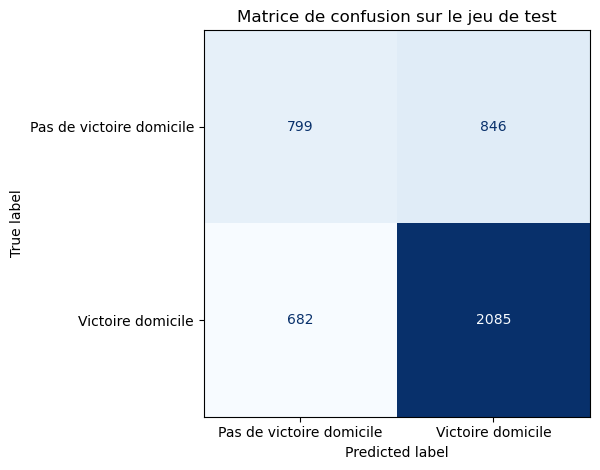

In [19]:
ConfusionMatrixDisplay.from_estimator(
    model, X_test_scaled, y_test,
    display_labels=["Pas de victoire domicile", "Victoire domicile"],
    cmap="Blues", colorbar=False,
)
plt.title("Matrice de confusion sur le jeu de test")
plt.tight_layout()
plt.show()

Lecture rapide : la diagonale (en haut à gauche, en bas à droite), ce sont les bonnes prédictions. Hors diagonale, les erreurs. Tu remarqueras que le modèle se trompe plus souvent en prédisant "victoire à domicile" à tort qu'en la ratant : il a intégré que le terrain avantage l'équipe qui reçoit, et a tendance à lui faire un peu trop confiance.

### Qu'est-ce qui fait gagner un match ?

Bonus très apprécié des forêts aléatoires : elles peuvent nous dire quelles features ont le plus pesé dans leurs décisions. De quoi répondre à la taverne avec des arguments :

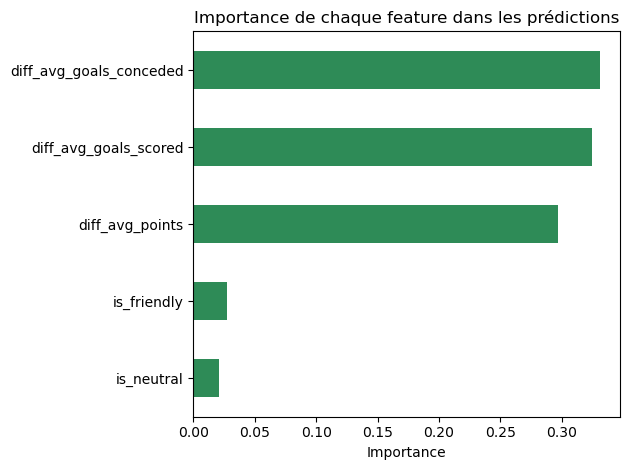

In [20]:
importances = pd.Series(model.feature_importances_, index=FEATURES).sort_values()

importances.plot(kind="barh", color="seagreen")
plt.title("Importance de chaque feature dans les prédictions")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

Verdict sans appel : ce sont les trois écarts de forme (points, buts marqués, buts encaissés) qui dominent, loin devant le terrain neutre et le type de match. Autrement dit : la dynamique récente des équipes, voilà ce qui prédit un match. Les intuitions de la taverne n'avaient pas tout faux, elles manquaient juste de chiffres.

# Partie 4 - Conclusion : L'heure du Pari !

C'est enfin l'heure du pari. Tes amis se penchent sur la table : le modèle est entraîné, il ne reste qu'à lui demander qui va gagner le finale de la coupe !

Pour cela, Il nous faut une fonction `predict_match(team_a, team_b)` qui fait exactement ce que le modèle a appris : comparer la forme récente des deux équipes. Bonne nouvelle, `utils.py` fournit `get_current_form(df, team)` qui calcule la forme actuelle d'une équipe (points, buts marqués, buts encaissés en moyenne sur ses 10 derniers matchs). Note qu'on utilise `df` (tous les matchs, nuls compris) et pas `data` : la forme d'une équipe inclut ses nuls !

À toi d'assembler la prédiction, en respectant scrupuleusement l'ordre des `FEATURES` (le modèle a appris dans cet ordre) :

1. Récupère la forme des deux équipes avec `get_current_form(df, team_a)` et `get_current_form(df, team_b)`
2. Construis la ligne de features : les 3 différences (équipe A moins équipe B), puis `is_neutral=1`, puis `is_friendly=0`
3. Standardise cette ligne avec `scaler.transform(features)`
4. Récupère la probabilité que l'équipe A gagne : `model.predict_proba(...)` renvoie `[[proba_classe_0, proba_classe_1]]`, la classe 1 étant la victoire de l'équipe "à domicile", ici l'équipe A

> Indice : pour l'étape 2, crée un DataFrame d'une seule ligne avec `pd.DataFrame([[...]], columns=FEATURES)`, le scaler retrouvera ses colonnes.

In [25]:
def predict_match(team_a, team_b):
    """Predict the winner of a match between two teams on neutral ground.

    Arguments:
    team_a -- name of the first team, e.g. 'France'
    team_b -- name of the second team, e.g. 'Brazil'

    Returns:
    winner -- name of the predicted winner
    probability -- probability of the winner winning (between 0.5 and 1)
    """

    ### START CODE HERE ###

    # 1. Forme récente des deux équipes
    form_a = get_current_form(df, team_a)
    form_b = get_current_form(df, team_b)

    # 2. Construction des features dans l'ordre de FEATURES
    features = pd.DataFrame(
        [[
            form_a["avg_points"] - form_b["avg_points"],
            form_a["avg_goals_scored"] - form_b["avg_goals_scored"],
            form_a["avg_goals_conceded"] - form_b["avg_goals_conceded"],
            1,  # is_neutral
            0   # is_friendly
        ]],
        columns=FEATURES
    )

    # 3. Standardisation
    features_scaled = scaler.transform(features)

    # 4. Probabilité que l'équipe A gagne
    proba_a_wins = model.predict_proba(features_scaled)[0, 1]

    ### END CODE HERE ###

    if proba_a_wins >= 0.5:
        return team_a, proba_a_wins
    return team_b, 1 - proba_a_wins

winner, proba = predict_match("France", "Brazil")
print(winner, proba)

winner, proba = predict_match("Argentina", "Spain")
print(f"Gagnant prédit : {winner} ({proba:.1%})")

winner, probability = predict_match("France", "Greece")
print(f"France vs Grèce -> victoire de {winner} ({probability:.0%})")

assert winner == "France", "Désolé pour la Grèce, mais la France devrait l'emporter ici. Vérifie l'ordre des features."
assert 0.5 <= probability <= 1, "La probabilité du vainqueur doit être entre 0.5 et 1"
winner_2, probability_2 = predict_match("Greece", "France")
assert winner_2 == "France", "La prédiction doit donner le même vainqueur dans les deux sens !"
print("Exercice validé !")

France 0.9506666666666667
Gagnant prédit : Argentina (77.7%)
France vs Grèce -> victoire de France (88%)
Exercice validé !


Super ! A présent... il ne reste plus qu'à s'amuser ! Utilise cette fonction pour prédire qui va gagner la finale de la coupe du monde 2026 (ou bien l'une des demi-finale si tu réalises ce projet en avance).

Tu peux tester le France - Argentine, ou bien France - Danemark.. ou encore Espagne - Angleterre... A toi de voir :)

Partage le résultat en commentaire sur la platforme !

In [26]:
### START CODE HERE ###
winner, probability = predict_match("France", "Argentina")
print(f"🏆 Vainqueur prédit : {winner}")
print(f"📊 Probabilité : {probability:.2%}")

winner, probability = predict_match("France", "Denmark")
print(f"🏆 Vainqueur prédit : {winner}")
print(f"📊 Probabilité : {probability:.2%}")

winner, probability = predict_match("Spain", "England")
print(f"🏆 Vainqueur prédit : {winner}")
print(f"📊 Probabilité : {probability:.2%}")


matches = [
    ("France", "Argentina"),
    ("France", "Denmark"),
    ("Spain", "England"),
    ("Brazil", "Portugal"),
]

for team_a, team_b in matches:
    winner, probability = predict_match(team_a, team_b)
    print(f"{team_a} vs {team_b} -> {winner} ({probability:.2%})")
    ### END CODE HERE ###

🏆 Vainqueur prédit : Argentina
📊 Probabilité : 73.48%
🏆 Vainqueur prédit : France
📊 Probabilité : 93.30%
🏆 Vainqueur prédit : Spain
📊 Probabilité : 64.86%
France vs Argentina -> Argentina (73.48%)
France vs Denmark -> France (93.30%)
Spain vs England -> Spain (64.86%)
Brazil vs Portugal -> Brazil (50.42%)


# Partie 5 (BONUS) - Simuler toute La Coupe du Monde 2030, match après match

Avec ce modele, nous pouvons également nous amuser à simuler l'évolution possible de toute un tournoi !

Pour l'illustrer, je propose qu'on se penche sur la CDM de 2030.

Celle-ci se jouera en Espagne, au Portugal et au Maroc, avec un format à 48 équipes. Pour rester simples, on imagine une phase finale à l'ancienne : **32 équipes plausibles, un tableau à élimination directe, des seizièmes de finale jusqu'à la finale**. Autres simplifications assumées : tous les matchs sur terrain neutre, aucun match amical, et pas de match nul possible (le modèle tranche toujours, comme les tirs au but).

Le principe de la simulation est élégant : le modèle prédit chaque match du tableau, **les vainqueurs avancent au tour suivant**, et on répète jusqu'à ce qu'il ne reste qu'une équipe. 16 matchs, puis 8, puis 4, puis 2, puis la finale : 31 prédictions pour un champion.

Voici notre tableau des seizièmes (chaque paire est un match, et les vainqueurs de deux matchs voisins se rencontrent au tour suivant) :

In [27]:
round_of_32 = [
    ("Spain", "Greece"), ("Denmark", "Ecuador"),
    ("Argentina", "Egypt"), ("Netherlands", "Poland"),
    ("France", "Nigeria"), ("Croatia", "South Korea"),
    ("England", "Canada"), ("Italy", "Senegal"),
    ("Portugal", "Australia"), ("Belgium", "Turkey"),
    ("Brazil", "Ghana"), ("Uruguay", "Switzerland"),
    ("Morocco", "Serbia"), ("Mexico", "Austria"),
    ("Germany", "Colombia"), ("Japan", "United States"),
]

print("Les 32 qualifiés de notre Coupe du Monde 2030 :\n")
for team_a, team_b in round_of_32:
    print(f"  {team_label(team_a):<22} vs {team_label(team_b)}")

assert len(round_of_32) == 16, "Il faut 16 matchs de seizièmes"
print("\n(Ta nation préférée n'y est pas ? Tu pourras modifier le tableau à la fin !)")

Les 32 qualifiés de notre Coupe du Monde 2030 :

  🇪🇸 Spain               vs 🇬🇷 Greece
  🇩🇰 Denmark             vs 🇪🇨 Ecuador
  🇦🇷 Argentina           vs 🇪🇬 Egypt
  🇳🇱 Netherlands         vs 🇵🇱 Poland
  🇫🇷 France              vs 🇳🇬 Nigeria
  🇭🇷 Croatia             vs 🇰🇷 South Korea
  🏴󠁧󠁢󠁥󠁮󠁧󠁿 England        vs 🇨🇦 Canada
  🇮🇹 Italy               vs 🇸🇳 Senegal
  🇵🇹 Portugal            vs 🇦🇺 Australia
  🇧🇪 Belgium             vs 🇹🇷 Turkey
  🇧🇷 Brazil              vs 🇬🇭 Ghana
  🇺🇾 Uruguay             vs 🇨🇭 Switzerland
  🇲🇦 Morocco             vs 🇷🇸 Serbia
  🇲🇽 Mexico              vs 🇦🇹 Austria
  🇩🇪 Germany             vs 🇨🇴 Colombia
  🇯🇵 Japan               vs 🇺🇸 United States

(Ta nation préférée n'y est pas ? Tu pourras modifier le tableau à la fin !)


### Simuler le tournoi en entier

Tout est prêt pour la grande simulation. La logique du tournoi t'est fournie : une liste de matchs par tour, et les vainqueurs de deux matchs voisins qui se rencontrent au tour suivant (`zip(winners[::2], winners[1::2])` forme ces nouvelles paires).

À toi d'écrire le coeur de la boucle : pour chaque match du tour, prédire le vainqueur avec ta fonction `predict_match`, l'ajouter à la liste `winners`, et garder une trace `(team_a, team_b, winner, probability)` dans `results` pour l'affichage.

In [31]:
current_round = round_of_32
all_results = []

for round_name in ROUND_NAMES:
    results = []
    winners = []

    for team_a, team_b in current_round:

        ### START CODE HERE ###
        winner, probability = predict_match(team_a, team_b)

        winners.append(winner)
        results.append((team_a, team_b, winner, probability))
        ### END CODE HERE ###

    print_round(round_name, results)
    all_results.extend(results)
    current_round = list(zip(winners[::2], winners[1::2]))

champion = winners[0]
print_champion(champion)

assert len(all_results) == 31, f"Un tableau à 32 équipes compte 31 matchs, tu en as simulé {len(all_results)}"
assert champion in [team for match in round_of_32 for team in match], "Le champion doit venir du tableau de départ !"

print("Simulation terminée, exercice validé !")


  SEIZIÈMES DE FINALE
🇪🇸 Spain               vs 🇬🇷 Greece              -> 🇪🇸 Spain (93%)
🇩🇰 Denmark             vs 🇪🇨 Ecuador             -> 🇩🇰 Denmark (58%)
🇦🇷 Argentina           vs 🇪🇬 Egypt               -> 🇦🇷 Argentina (96%)
🇳🇱 Netherlands         vs 🇵🇱 Poland              -> 🇳🇱 Netherlands (83%)
🇫🇷 France              vs 🇳🇬 Nigeria             -> 🇳🇬 Nigeria (51%)
🇭🇷 Croatia             vs 🇰🇷 South Korea         -> 🇭🇷 Croatia (67%)
🏴󠁧󠁢󠁥󠁮󠁧󠁿 England        vs 🇨🇦 Canada              -> 🏴󠁧󠁢󠁥󠁮󠁧󠁿 England (81%)
🇮🇹 Italy               vs 🇸🇳 Senegal             -> 🇮🇹 Italy (83%)
🇵🇹 Portugal            vs 🇦🇺 Australia           -> 🇦🇺 Australia (80%)
🇧🇪 Belgium             vs 🇹🇷 Turkey              -> 🇧🇪 Belgium (72%)
🇧🇷 Brazil              vs 🇬🇭 Ghana               -> 🇧🇷 Brazil (95%)
🇺🇾 Uruguay             vs 🇨🇭 Switzerland         -> 🇺🇾 Uruguay (76%)
🇲🇦 Morocco             vs 🇷🇸 Serbia              -> 🇲🇦 Morocco (98%)
🇲🇽 Mexico              vs 🇦🇹 Austria             -> 🇲🇽 Mexico (77%)
🇩🇪 G

### Le parcours du champion

Pour le fun, voici un petit graphique sympa :)

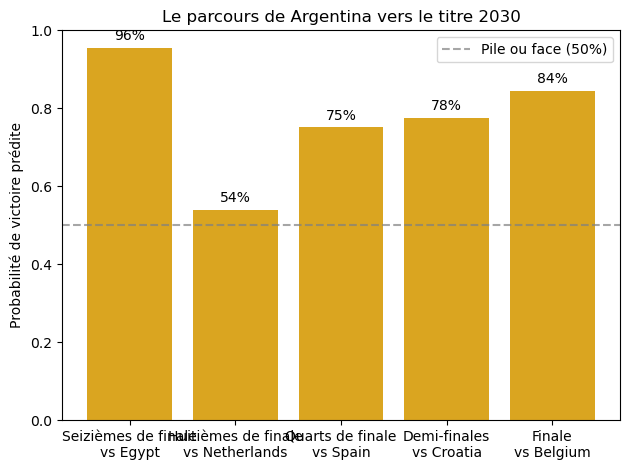

In [32]:
champion_matches = [match for match in all_results if match[2] == champion]
opponents = [f"{name}\nvs {team_a if team_b == champion else team_b}"
             for name, (team_a, team_b, _, _) in zip(ROUND_NAMES, champion_matches)]
probabilities = [match[3] for match in champion_matches]

bars = plt.bar(opponents, probabilities, color="goldenrod")
plt.axhline(0.5, color="gray", linestyle="--", alpha=0.7, label="Pile ou face (50%)")
plt.ylim(0, 1)
plt.ylabel("Probabilité de victoire prédite")
plt.title(f"Le parcours de {champion} vers le titre 2030")
plt.legend()
for bar, prob in zip(bars, probabilities):
    plt.text(bar.get_x() + bar.get_width() / 2, prob + 0.02, f"{prob:.0%}", ha="center")
plt.tight_layout()
plt.show()

Regarde bien les probabilités : certains matchs se jouent à presque pile ou face. C'est l'honnêteté du Machine Learning : le modèle ne prétend pas connaître l'avenir, il donne son degré de confiance. Sur 31 matchs à ~65% de fiabilité chacun, il suffit d'une surprise pour changer tout le tableau... exactement comme dans une vraie Coupe du Monde.

De retour à la taverne, tu annonces ton pronostic. Silence. Puis Yannis hausse les épaules : "on verra bien en 2030 !".

Le Rendez-vous est pris.

### Pour aller plus loin (si tu veux briller encore plus)

Quelques idées à tester par toi-même : donner l'avantage du terrain à l'Espagne, au Portugal et au Maroc (les hôtes) en passant `is_neutral` à 0 pour leurs matchs, modifier le tableau des 32 qualifiés selon tes convictions, agrandir ou réduire la fenêtre de forme (`window=10`), Effectuer une simulation de Monte Carlo, ou encore afficher les 3 classes victoire/nul/défaite au lieu du binaire. Le notebook est à toi !

---

# Bilan

Il est tard, la taverne ferme, et tu viens de dérouler ton premier projet de Machine Learning de bout en bout : explorer des données réelles avec des graphiques, les préparer (features, encodage, standardisation, découpage train/test), entraîner et évaluer un modèle, puis l'utiliser pour répondre à une vraie question, itérativement, match après match. C'est exactement ce workflow, explorer, préparer, modéliser, prédire, que tu retrouveras dans tous les projets de data science, du pronostic sportif à la détection de fraude.

Et souviens-toi du chiffre le plus important du projet : 66%. Un bon modèle n'est pas un modèle qui a toujours raison, c'est un modèle dont on connaît honnêtement les limites.

Question : Qu'as-tu appris à travers ce projet ? La meilleure Pépitte ? Dis le moi en commentaire sur la plateforme, ca m'intéresse ! :)


Rendez-vous dimanche prochain pour le troisième projet. Bonnes vacances !